# Belief shapes, side by side

The scalar soft-label formalism collapses an interaction's quality to a single number `p = P(v = +1)`. beta-swarm instead carries a **Beta(α, β) belief** over the continuous outcome `v ∈ [0, 1]`, which exposes two interpretable quantities:

- **mean** = `α / (α + β)` — recovers the old point estimate `p`
- **concentration** = `α + β` — epistemic certainty (new)

This notebook draws the belief *shapes* so you can see what the mean throws away. Everything below uses only `beta_swarm`, `numpy`, and `matplotlib`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # import beta_swarm without install

import numpy as np
import matplotlib.pyplot as plt

from beta_swarm import BetaBelief, TailMassGovernor, DistributionalMetrics
from beta_swarm.interaction import BetaInteraction
from beta_swarm.metrics import wasserstein1_mixtures

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
v = np.linspace(0, 1, 400)

## 1. Same mean, different shape

The motivating case. Both beliefs have **mean = 0.5** — a scalar-`p` policy assigns each `p = 0.5` and cannot tell them apart. But one is *confidently mediocre* (sharp) and the other is *uncertain great-or-terrible* (diffuse). The shaded region is the downside tail `P(v < τ)` that governance acts on.

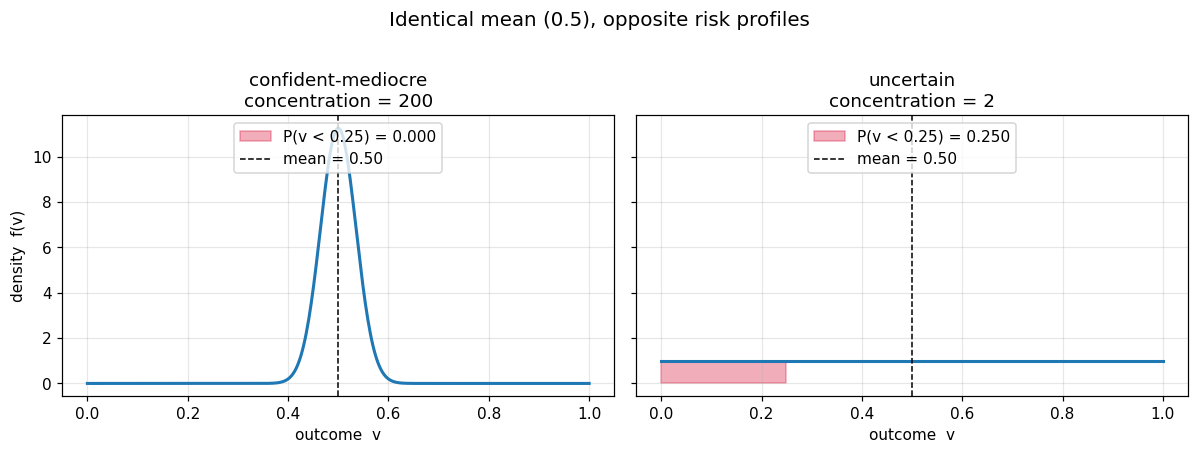

In [2]:
tau = 0.25
pairs = [
    ('confident-mediocre', BetaBelief.from_mean_concentration(0.5, 200.0)),
    ('uncertain',          BetaBelief.from_mean_concentration(0.5, 2.0)),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (name, b) in zip(axes, pairs):
    pdf = b.pdf(v)
    ax.plot(v, pdf, lw=2)
    ax.fill_between(v, pdf, where=(v < tau), alpha=0.35, color='crimson',
                    label=f'P(v < {tau}) = {b.tail_mass(tau):.3f}')
    ax.axvline(b.mean, color='k', ls='--', lw=1, label=f'mean = {b.mean:.2f}')
    ax.set_title(f'{name}\nconcentration = {b.concentration:.0f}')
    ax.set_xlabel('outcome  v'); ax.legend(loc='upper center')
axes[0].set_ylabel('density  f(v)')
fig.suptitle('Identical mean (0.5), opposite risk profiles', y=1.02, fontsize=13)
fig.tight_layout(); plt.show()

## 2. The shape catalog: sweeping mean × concentration

A grid of belief shapes. Reading **down a column** holds the mean fixed and increases concentration — the belief sharpens around the same point. Reading **across a row** holds concentration fixed and shifts the mean. The top-left corner (low mean, low concentration) is the dangerous regime: a belief that is both pessimistic *and* unsure.

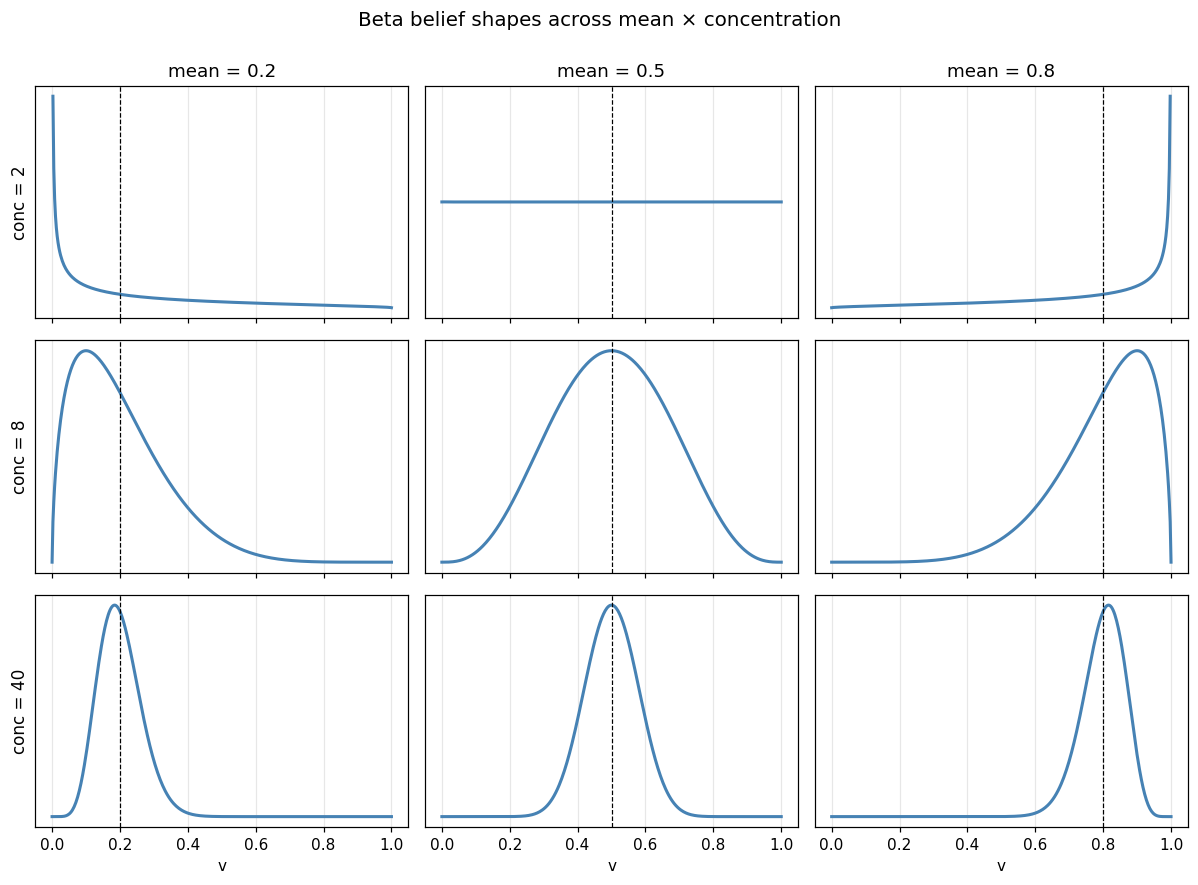

In [3]:
means = [0.2, 0.5, 0.8]
concentrations = [2.0, 8.0, 40.0]

fig, axes = plt.subplots(len(concentrations), len(means),
                         figsize=(11, 8), sharex=True)
for r, conc in enumerate(concentrations):
    for c, mean in enumerate(means):
        ax = axes[r][c]
        b = BetaBelief.from_mean_concentration(mean, conc)
        ax.plot(v, b.pdf(v), lw=2, color='steelblue')
        ax.axvline(mean, color='k', ls='--', lw=0.8)
        ax.set_yticks([])
        if r == 0:
            ax.set_title(f'mean = {mean}')
        if c == 0:
            ax.set_ylabel(f'conc = {conc:.0f}', fontsize=11)
        if r == len(concentrations) - 1:
            ax.set_xlabel('v')
fig.suptitle('Beta belief shapes across mean × concentration', y=1.0, fontsize=13)
fig.tight_layout(); plt.show()

## 3. Cumulative view: where the governor reads the tail

Governance triggers on the CDF value `P(v < τ)`. Plotting the CDFs makes the lever explicit: at the threshold `τ`, the height of each curve *is* the tail mass. The two same-mean beliefs cross at the mean but separate sharply in the tail.

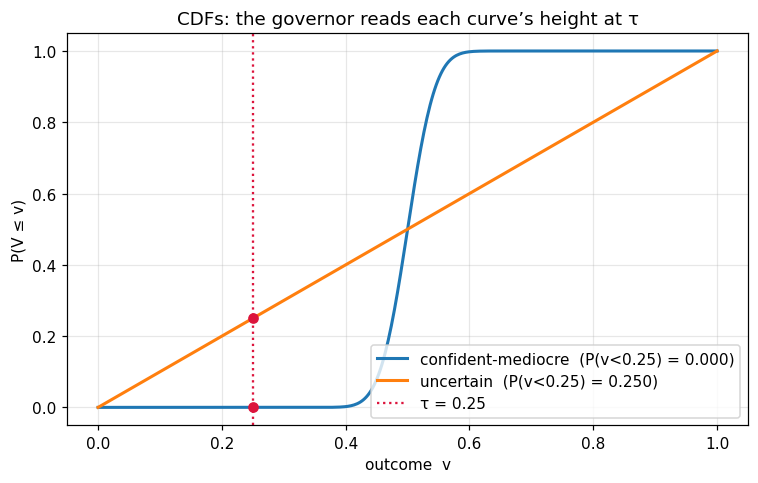

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, b in pairs:
    ax.plot(v, b.cdf(v), lw=2, label=f'{name}  (P(v<{tau}) = {b.tail_mass(tau):.3f})')
ax.axvline(tau, color='crimson', ls=':', lw=1.5, label=f'τ = {tau}')
ax.scatter([tau, tau], [b.tail_mass(tau) for _, b in pairs], color='crimson', zorder=5)
ax.set_xlabel('outcome  v'); ax.set_ylabel('P(V ≤ v)')
ax.set_title('CDFs: the governor reads each curve’s height at τ')
ax.legend(); fig.tight_layout(); plt.show()

## 4. Accepted vs rejected populations: the quality gap as a distance

In the scalar formalism the quality gap was `E[p|accepted] − E[p|rejected]` — a difference of two numbers. With full beliefs it becomes a **distance between two distributions**: the mixture of accepted beliefs vs. the mixture of rejected ones. Below we build an adversely-selected population (accepted interactions are *lower* quality) and overlay the two mixture densities; the Wasserstein-1 distance summarizes their separation.

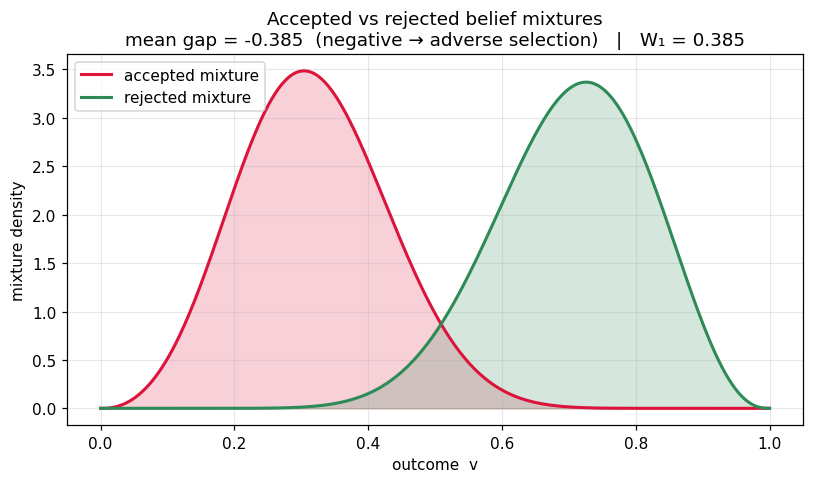

In [5]:
rng = np.random.default_rng(7)

def make_ix(mean, conc, accepted):
    return BetaInteraction(belief=BetaBelief.from_mean_concentration(mean, conc),
                           accepted=accepted)

# Adverse selection: accepted ~ low quality, rejected ~ high quality.
interactions = (
    [make_ix(np.clip(rng.normal(0.35, 0.08), 0.05, 0.95), 25, True)  for _ in range(40)] +
    [make_ix(np.clip(rng.normal(0.70, 0.08), 0.05, 0.95), 25, False) for _ in range(40)]
)

acc = [i.belief for i in interactions if i.accepted]
rej = [i.belief for i in interactions if not i.accepted]

def mixture_pdf(beliefs):
    return np.mean([b.pdf(v) for b in beliefs], axis=0)

m = DistributionalMetrics()
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(v, mixture_pdf(acc), lw=2, color='crimson', label='accepted mixture')
ax.plot(v, mixture_pdf(rej), lw=2, color='seagreen', label='rejected mixture')
ax.fill_between(v, mixture_pdf(acc), alpha=0.2, color='crimson')
ax.fill_between(v, mixture_pdf(rej), alpha=0.2, color='seagreen')
ax.set_xlabel('outcome  v'); ax.set_ylabel('mixture density')
ax.set_title(
    f'Accepted vs rejected belief mixtures\n'
    f'mean gap = {m.mean_quality_gap(interactions):+.3f}  (negative → adverse selection)   |   '
    f'W₁ = {m.quality_gap_wasserstein(interactions):.3f}'
)
ax.legend(); fig.tight_layout(); plt.show()

The negative **mean gap** flags adverse selection (the market accepts worse-than-rejected interactions); the positive **Wasserstein-1** distance quantifies *how far apart* the two populations are as full distributions — a richer summary than the signed difference of means alone.

## 5. Tail mass over the (mean, concentration) plane

The previous plots show individual shapes; this one maps the governor's lever across the whole belief space. Each point is a `Beta` belief parameterized by its mean (x) and concentration (y); the color is the downside tail mass `P(v < τ)` it implies.

Two things to read off it:

- Along any **horizontal line** (fixed concentration) the tail rises smoothly as the mean falls — the scalar-`p` intuition.
- Along any **vertical line** (fixed mean) the tail still changes: low concentration inflates the tail even at a high mean. That vertical variation is exactly what a mean-only policy is blind to. A horizontal `max_tail_mass` contour therefore carves a curved admission boundary — to clear the same risk bar, a less-certain belief needs a higher mean.

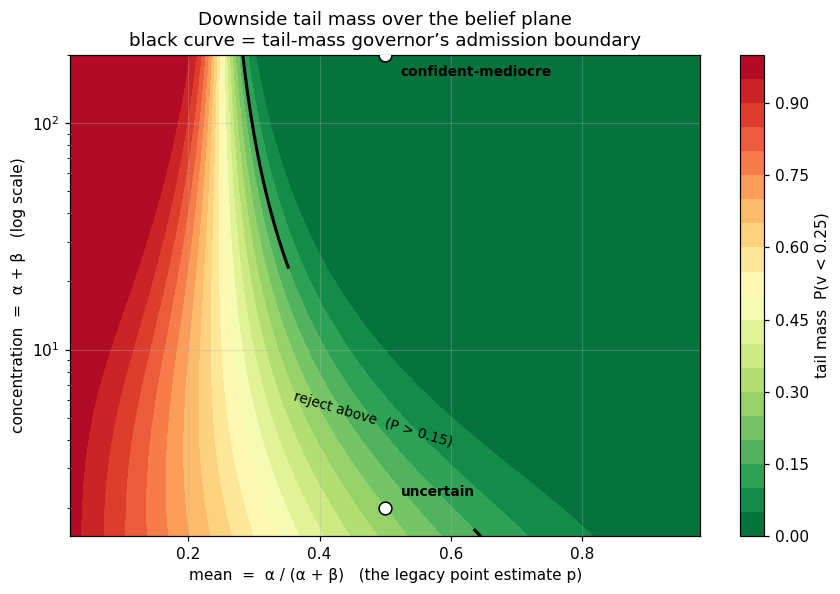

In [6]:
mean_grid = np.linspace(0.02, 0.98, 200)
conc_grid = np.logspace(np.log10(1.5), np.log10(200), 200)  # log scale: certainty spans orders of magnitude
MM, CC = np.meshgrid(mean_grid, conc_grid)

# Tail mass P(v < tau) at every (mean, concentration) point.
TM = np.vectorize(lambda m, c: BetaBelief.from_mean_concentration(m, c).tail_mass(tau))(MM, CC)

fig, ax = plt.subplots(figsize=(8, 5.5))
filled = ax.contourf(MM, CC, TM, levels=np.linspace(0, 1, 21), cmap='RdYlGn_r')
cbar = fig.colorbar(filled, ax=ax); cbar.set_label(f'tail mass  P(v < {tau})')

# Overlay the governor's admission boundary: the max_tail_mass contour.
max_tail = 0.15
boundary = ax.contour(MM, CC, TM, levels=[max_tail], colors='black', linewidths=2)
ax.clabel(boundary, fmt=f'reject above  (P > {max_tail})', fontsize=9)

# Mark the two same-mean beliefs from section 1. Offset labels to avoid the
# top edge / title collision for the high-concentration point.
label_offset = {'confident-mediocre': (10, -14), 'uncertain': (10, 8)}
for name, b in pairs:
    ax.scatter(b.mean, b.concentration, s=70, edgecolor='k', zorder=5, color='white')
    ax.annotate(name, (b.mean, b.concentration), textcoords='offset points',
                xytext=label_offset[name], fontsize=9, fontweight='bold')

ax.set_yscale('log')
ax.set_ylim(1.5, 200)
ax.set_xlabel('mean  =  α / (α + β)   (the legacy point estimate p)')
ax.set_ylabel('concentration  =  α + β   (log scale)')
ax.set_title('Downside tail mass over the belief plane\n'
             'black curve = tail-mass governor’s admission boundary')
fig.tight_layout(); plt.show()